In [1]:
#------使用XGB模型-透射光谱-使用光谱预处理方法-融合RGB------#
#------储存路径代号：XGB_Fusion_02------#

In [2]:
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from utils.train_log import EvaluationMetricsLogger,PredictionSaver
from utils import datalodaer,model_trainer,preprocess,utils,ploter

import pandas as pd
import numpy as np
from datetime import datetime

# 设置全局字体为 "Times New Roman"
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 9         # 设置全局字体大小
plt.rcParams['axes.unicode_minus'] = False  # 设置支持负号显示
plt.rcParams['svg.fonttype'] = 'none'

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

series_path = '08-XGBoost-TS&Lab-Preprocessing'

In [3]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
labels_file = project_root / 'data/labels'
image_features_path = project_root / 'data/pictures/lab_features.csv'
logger = EvaluationMetricsLogger()
saver = PredictionSaver()


加载现有日志文件: ../results/model_evaluation/evaluation_metrics_log.csv，包含 450 条记录
加载现有预测文件: ../results/model_evaluation/predictions_log.csv，包含 2790 条预测记录


In [4]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

[I 2026-02-26 16:05:08,517] A new study created in memory with name: xgb_optuna_tuning


NO.1 [正在训练: PH | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 79
  最优参数: {'learning_rate': 0.01871583214870972, 'max_depth': 6, 'min_child_weight': 8.822246373838924, 'subsample': 0.5102368135636264, 'colsample_bytree': 0.9245555442089065, 'reg_lambda': 0.011991005205424031, 'reg_alpha': 0.04323800309653134, 'gamma': 0.00016701748475835}
  最优验证集 RMSE: 0.07086998224258423
  对应 best_iteration: 435
预测结果已保存OK
实验记录已保存: PH-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9075, 验证集 R²: 0.6740, 测试集 R²: 0.5016



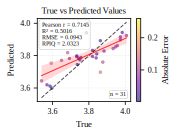

NO.2 [正在训练: PH | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 93
  最优参数: {'learning_rate': 0.05659771537734018, 'max_depth': 7, 'min_child_weight': 4.602815029266898, 'subsample': 0.5922008282186759, 'colsample_bytree': 0.6313557410527632, 'reg_lambda': 0.07071046617806075, 'reg_alpha': 0.0025564763123884543, 'gamma': 0.005792612222385448}
  最优验证集 RMSE: 0.07605627924203873
  对应 best_iteration: 243
预测结果已保存OK
实验记录已保存: PH-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9684, 验证集 R²: 0.6245, 测试集 R²: 0.4746



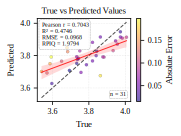

NO.3 [正在训练: PH | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 93
  最优参数: {'learning_rate': 0.012179441251859767, 'max_depth': 6, 'min_child_weight': 3.2963074007866133, 'subsample': 0.5398296550523108, 'colsample_bytree': 0.8712591729623355, 'reg_lambda': 0.004741484141711864, 'reg_alpha': 0.004639109715925275, 'gamma': 0.005786731140070408}
  最优验证集 RMSE: 0.08488412201404572
  对应 best_iteration: 262
预测结果已保存OK
实验记录已保存: PH-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9404, 验证集 R²: 0.5323, 测试集 R²: 0.3111



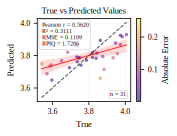

NO.4 [正在训练: PH | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 99
  最优参数: {'learning_rate': 0.02165770460956987, 'max_depth': 5, 'min_child_weight': 2.2657014606068038, 'subsample': 0.5430370639365176, 'colsample_bytree': 0.929270553210987, 'reg_lambda': 0.027226596474354207, 'reg_alpha': 0.01122194567480053, 'gamma': 0.017268590235980832}
  最优验证集 RMSE: 0.08437924832105637
  对应 best_iteration: 115
预测结果已保存OK
实验记录已保存: PH-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.8779, 验证集 R²: 0.5378, 测试集 R²: 0.3500



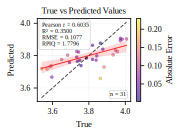

NO.5 [正在训练: PH | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 53
  最优参数: {'learning_rate': 0.08305763481435273, 'max_depth': 2, 'min_child_weight': 4.822210406749517, 'subsample': 0.7035108250589487, 'colsample_bytree': 0.6104322404170714, 'reg_lambda': 0.6122226505457801, 'reg_alpha': 0.17809131904641642, 'gamma': 0.006068399457391015}
  最优验证集 RMSE: 0.07098076492547989
  对应 best_iteration: 45
预测结果已保存OK
实验记录已保存: PH-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9249, 验证集 R²: 0.6730, 测试集 R²: 0.6483



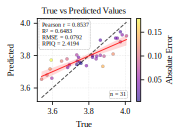

NO.6 [正在训练: PH | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 77
  最优参数: {'learning_rate': 0.02249207063661284, 'max_depth': 8, 'min_child_weight': 3.2770868528975594, 'subsample': 0.6555212436810631, 'colsample_bytree': 0.54240521008031, 'reg_lambda': 0.011174908883420702, 'reg_alpha': 0.15419775442829636, 'gamma': 0.003482512298225226}
  最优验证集 RMSE: 0.0599253810942173
  对应 best_iteration: 500
预测结果已保存OK
实验记录已保存: PH-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9623, 验证集 R²: 0.7669, 测试集 R²: 0.6623



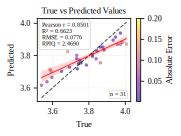

NO.7 [正在训练: GLU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 87
  最优参数: {'learning_rate': 0.0038125405455208218, 'max_depth': 8, 'min_child_weight': 9.996504745234454, 'subsample': 0.5288204984310646, 'colsample_bytree': 0.35144993378261824, 'reg_lambda': 0.0016079272351154682, 'reg_alpha': 0.029052279999560265, 'gamma': 2.73933576977631}
  最优验证集 RMSE: 1.7894384860992432
  对应 best_iteration: 759
预测结果已保存OK
实验记录已保存: GLU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.8402, 验证集 R²: 0.6672, 测试集 R²: 0.6464



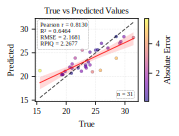

NO.8 [正在训练: GLU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 66
  最优参数: {'learning_rate': 0.009536435175245916, 'max_depth': 2, 'min_child_weight': 9.411030996806982, 'subsample': 0.7618115599685823, 'colsample_bytree': 0.9570066275593463, 'reg_lambda': 0.01591105454094209, 'reg_alpha': 0.004512385545432498, 'gamma': 0.34008325725978694}
  最优验证集 RMSE: 1.468544602394104
  对应 best_iteration: 1000
预测结果已保存OK
实验记录已保存: GLU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9793, 验证集 R²: 0.7759, 测试集 R²: 0.7423



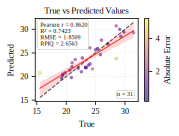

NO.9 [正在训练: GLU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 87
  最优参数: {'learning_rate': 0.055579986508286286, 'max_depth': 4, 'min_child_weight': 6.407538595294001, 'subsample': 0.5100063483485275, 'colsample_bytree': 0.9094653903732978, 'reg_lambda': 0.037115168275633215, 'reg_alpha': 0.0014435929263318709, 'gamma': 1.058291153190218}
  最优验证集 RMSE: 1.4738364219665527
  对应 best_iteration: 88
预测结果已保存OK
实验记录已保存: GLU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9572, 验证集 R²: 0.7743, 测试集 R²: 0.7156



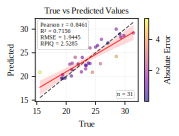

NO.10 [正在训练: GLU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 79
  最优参数: {'learning_rate': 0.07042120746356006, 'max_depth': 2, 'min_child_weight': 1.1276113602714923, 'subsample': 0.5410606676279298, 'colsample_bytree': 0.5841484226822274, 'reg_lambda': 1.6670421091231644, 'reg_alpha': 0.15769290096590124, 'gamma': 2.045199601269319}
  最优验证集 RMSE: 1.4083380699157715
  对应 best_iteration: 209
预测结果已保存OK
实验记录已保存: GLU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9679, 验证集 R²: 0.7939, 测试集 R²: 0.7173



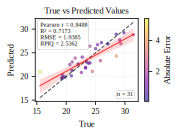

NO.11 [正在训练: GLU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 87
  最优参数: {'learning_rate': 0.03032033764065181, 'max_depth': 5, 'min_child_weight': 1.4305908749198808, 'subsample': 0.5103079555629952, 'colsample_bytree': 0.6674938896775462, 'reg_lambda': 6.341776270716219, 'reg_alpha': 0.014983988912046308, 'gamma': 1.9943101739199234}
  最优验证集 RMSE: 1.5198355913162231
  对应 best_iteration: 243
预测结果已保存OK
实验记录已保存: GLU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9591, 验证集 R²: 0.7600, 测试集 R²: 0.7117



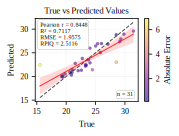

NO.12 [正在训练: GLU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 62
  最优参数: {'learning_rate': 0.013915113369633851, 'max_depth': 2, 'min_child_weight': 1.085548385485253, 'subsample': 0.5518836518489917, 'colsample_bytree': 0.6163471196441299, 'reg_lambda': 0.0016276462545446368, 'reg_alpha': 0.32189218278819687, 'gamma': 1.1976753652116807}
  最优验证集 RMSE: 1.2539271116256714
  对应 best_iteration: 698
预测结果已保存OK
实验记录已保存: GLU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9883, 验证集 R²: 0.8366, 测试集 R²: 0.7622



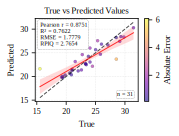

NO.13 [正在训练: 5-HMF | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 74
  最优参数: {'learning_rate': 0.007723298884228445, 'max_depth': 6, 'min_child_weight': 4.823661268130082, 'subsample': 0.5505911636761559, 'colsample_bytree': 0.9405828862223493, 'reg_lambda': 0.001005067417479507, 'reg_alpha': 0.00518618923107044, 'gamma': 2.6061970634414147}
  最优验证集 RMSE: 17.127592086791992
  对应 best_iteration: 459
预测结果已保存OK
实验记录已保存: 5-HMF-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9499, 验证集 R²: 0.9773, 测试集 R²: 0.8892



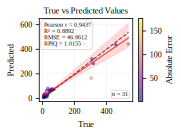

NO.14 [正在训练: 5-HMF | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 73
  最优参数: {'learning_rate': 0.013133539009180253, 'max_depth': 7, 'min_child_weight': 3.7933404188057946, 'subsample': 0.9706584684339884, 'colsample_bytree': 0.9812656059506673, 'reg_lambda': 5.050836641628917, 'reg_alpha': 4.96507048073422, 'gamma': 4.596062005117637}
  最优验证集 RMSE: 13.810023307800293
  对应 best_iteration: 251
预测结果已保存OK
实验记录已保存: 5-HMF-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9526, 验证集 R²: 0.9852, 测试集 R²: 0.9725



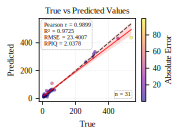

NO.15 [正在训练: 5-HMF | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 56
  最优参数: {'learning_rate': 0.013153697336350233, 'max_depth': 8, 'min_child_weight': 5.1619065848885635, 'subsample': 0.9823860459040811, 'colsample_bytree': 0.9537809006509277, 'reg_lambda': 6.551571033693437, 'reg_alpha': 0.3424674423883988, 'gamma': 0.9049307431268763}
  最优验证集 RMSE: 15.607933044433594
  对应 best_iteration: 291
预测结果已保存OK
实验记录已保存: 5-HMF-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9484, 验证集 R²: 0.9811, 测试集 R²: 0.9317



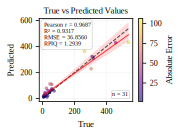

NO.16 [正在训练: 5-HMF | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 95
  最优参数: {'learning_rate': 0.02145397097697451, 'max_depth': 5, 'min_child_weight': 4.0077733424763995, 'subsample': 0.9074644923720033, 'colsample_bytree': 0.9519031239601665, 'reg_lambda': 18.462240151308876, 'reg_alpha': 0.005667118260291384, 'gamma': 2.3282357175589476}
  最优验证集 RMSE: 16.38008689880371
  对应 best_iteration: 327
预测结果已保存OK
实验记录已保存: 5-HMF-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9447, 验证集 R²: 0.9792, 测试集 R²: 0.9348



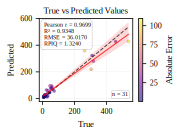

NO.17 [正在训练: 5-HMF | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 53
  最优参数: {'learning_rate': 0.07526740859372334, 'max_depth': 3, 'min_child_weight': 1.030508591875557, 'subsample': 0.8189870938218062, 'colsample_bytree': 0.5816926952663835, 'reg_lambda': 3.8134027494699407, 'reg_alpha': 0.19276363696946797, 'gamma': 2.600801552358008}
  最优验证集 RMSE: 14.580830574035645
  对应 best_iteration: 76
预测结果已保存OK
实验记录已保存: 5-HMF-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9934, 验证集 R²: 0.9835, 测试集 R²: 0.9626



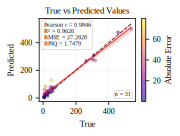

NO.18 [正在训练: 5-HMF | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 31
  最优参数: {'learning_rate': 0.0964859466849109, 'max_depth': 8, 'min_child_weight': 4.8461111090168885, 'subsample': 0.7936671744355059, 'colsample_bytree': 0.42215883638833607, 'reg_lambda': 45.47913019622979, 'reg_alpha': 0.00517734583792422, 'gamma': 4.066055516024939}
  最优验证集 RMSE: 22.844648361206055
  对应 best_iteration: 145
预测结果已保存OK
实验记录已保存: 5-HMF-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9544, 验证集 R²: 0.9596, 测试集 R²: 0.9353



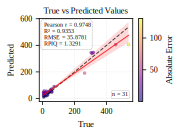

NO.19 [正在训练: Water | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 95
  最优参数: {'learning_rate': 0.008394861827064438, 'max_depth': 3, 'min_child_weight': 1.0887474786449216, 'subsample': 0.5191306774654814, 'colsample_bytree': 0.3008050269309496, 'reg_lambda': 4.821981121248201, 'reg_alpha': 0.010460178933502288, 'gamma': 1.1653920149959458}
  最优验证集 RMSE: 0.8201571702957153
  对应 best_iteration: 1683
预测结果已保存OK
实验记录已保存: Water-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9898, 验证集 R²: 0.9645, 测试集 R²: 0.9730



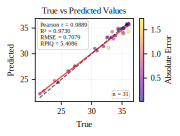

NO.20 [正在训练: Water | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 27
  最优参数: {'learning_rate': 0.09117989080902736, 'max_depth': 6, 'min_child_weight': 7.088193991305465, 'subsample': 0.5565436501269689, 'colsample_bytree': 0.415742384187329, 'reg_lambda': 11.876270508590533, 'reg_alpha': 0.5206868813067732, 'gamma': 3.874190863224092}
  最优验证集 RMSE: 0.8916974067687988
  对应 best_iteration: 451
预测结果已保存OK
实验记录已保存: Water-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9775, 验证集 R²: 0.9580, 测试集 R²: 0.9636



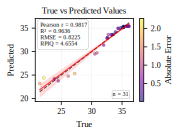

NO.21 [正在训练: Water | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 54
  最优参数: {'learning_rate': 0.04646247820682056, 'max_depth': 4, 'min_child_weight': 1.4847860428953383, 'subsample': 0.6260475643998322, 'colsample_bytree': 0.8837568092614634, 'reg_lambda': 2.96911054639695, 'reg_alpha': 0.005984090885835175, 'gamma': 1.1478057531919783}
  最优验证集 RMSE: 0.632382869720459
  对应 best_iteration: 371
预测结果已保存OK
实验记录已保存: Water-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9939, 验证集 R²: 0.9789, 测试集 R²: 0.9456



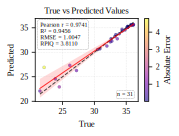

NO.22 [正在训练: Water | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 81
  最优参数: {'learning_rate': 0.0037115672254504294, 'max_depth': 3, 'min_child_weight': 1.1564544623657627, 'subsample': 0.5943201375083257, 'colsample_bytree': 0.8607295677034715, 'reg_lambda': 2.2650784240269277, 'reg_alpha': 0.007209820569139944, 'gamma': 1.024359903565689}
  最优验证集 RMSE: 0.5761877298355103
  对应 best_iteration: 2599
预测结果已保存OK
实验记录已保存: Water-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9954, 验证集 R²: 0.9825, 测试集 R²: 0.9751



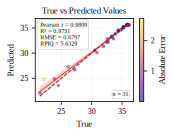

NO.23 [正在训练: Water | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 83
  最优参数: {'learning_rate': 0.004950281994877249, 'max_depth': 8, 'min_child_weight': 8.932369996349578, 'subsample': 0.5879981682002634, 'colsample_bytree': 0.5330378543160955, 'reg_lambda': 0.12856065127303026, 'reg_alpha': 0.0016384862643820943, 'gamma': 0.1589911003507073}
  最优验证集 RMSE: 0.6319372057914734
  对应 best_iteration: 2002
预测结果已保存OK
实验记录已保存: Water-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9983, 验证集 R²: 0.9789, 测试集 R²: 0.9818



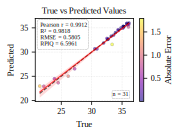

NO.24 [正在训练: Water | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 66
  最优参数: {'learning_rate': 0.0022465655023928026, 'max_depth': 7, 'min_child_weight': 8.560830447603655, 'subsample': 0.6794122967590208, 'colsample_bytree': 0.8461921632319872, 'reg_lambda': 0.011506539540990996, 'reg_alpha': 0.3912882059927352, 'gamma': 0.5428364199048229}
  最优验证集 RMSE: 0.5865876078605652
  对应 best_iteration: 3361
预测结果已保存OK
实验记录已保存: Water-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9968, 验证集 R²: 0.9818, 测试集 R²: 0.9890



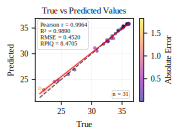

NO.25 [正在训练: FRU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 92
  最优参数: {'learning_rate': 0.08792531853573719, 'max_depth': 8, 'min_child_weight': 9.763188180628797, 'subsample': 0.6534502757798961, 'colsample_bytree': 0.5211955728864714, 'reg_lambda': 0.001014067003160624, 'reg_alpha': 0.5360938799110316, 'gamma': 1.7333488354982278}
  最优验证集 RMSE: 2.3463215827941895
  对应 best_iteration: 19
预测结果已保存OK
实验记录已保存: FRU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.7624, 验证集 R²: 0.6874, 测试集 R²: 0.4975



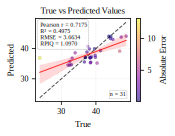

NO.26 [正在训练: FRU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 94
  最优参数: {'learning_rate': 0.038900042197343665, 'max_depth': 7, 'min_child_weight': 9.553647442112938, 'subsample': 0.568658571633567, 'colsample_bytree': 0.9879706039815994, 'reg_lambda': 80.80519928074969, 'reg_alpha': 1.0615450276872926, 'gamma': 1.478883655058207}
  最优验证集 RMSE: 2.3083653450012207
  对应 best_iteration: 1836
预测结果已保存OK
实验记录已保存: FRU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9372, 验证集 R²: 0.6974, 测试集 R²: 0.5472



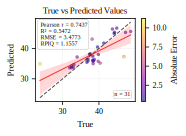

NO.27 [正在训练: FRU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 81
  最优参数: {'learning_rate': 0.018838806295251243, 'max_depth': 4, 'min_child_weight': 4.730726978805273, 'subsample': 0.9924566233147093, 'colsample_bytree': 0.7245297178833423, 'reg_lambda': 68.53536169339228, 'reg_alpha': 5.37927366097421, 'gamma': 2.2560159333539014}
  最优验证集 RMSE: 2.4451277256011963
  对应 best_iteration: 911
预测结果已保存OK
实验记录已保存: FRU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.8839, 验证集 R²: 0.6605, 测试集 R²: 0.5236



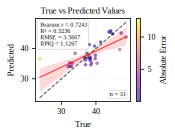

NO.28 [正在训练: FRU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 57
  最优参数: {'learning_rate': 0.05287379460202987, 'max_depth': 2, 'min_child_weight': 2.30719106841855, 'subsample': 0.8392801569896088, 'colsample_bytree': 0.6774196304000341, 'reg_lambda': 0.08299852654217972, 'reg_alpha': 0.09615249738061565, 'gamma': 3.7781979926622964}
  最优验证集 RMSE: 2.3490567207336426
  对应 best_iteration: 82
预测结果已保存OK
实验记录已保存: FRU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9341, 验证集 R²: 0.6867, 测试集 R²: 0.5433



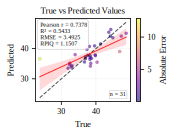

NO.29 [正在训练: FRU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 43
  最优参数: {'learning_rate': 0.05769794590859703, 'max_depth': 2, 'min_child_weight': 4.010726442639154, 'subsample': 0.5549605129192581, 'colsample_bytree': 0.6322612003144646, 'reg_lambda': 0.215882139942224, 'reg_alpha': 3.2509014040555644, 'gamma': 3.1470123592010624}
  最优验证集 RMSE: 2.2666516304016113
  对应 best_iteration: 89
预测结果已保存OK
实验记录已保存: FRU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9435, 验证集 R²: 0.7083, 测试集 R²: 0.5540



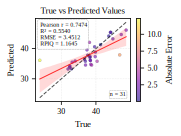

NO.30 [正在训练: FRU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 10
  最优参数: {'learning_rate': 0.05396116498834086, 'max_depth': 2, 'min_child_weight': 4.318558954489876, 'subsample': 0.5089809378074098, 'colsample_bytree': 0.6985187518566107, 'reg_lambda': 0.16420976667366668, 'reg_alpha': 6.903717055434688, 'gamma': 3.3342913754128913}
  最优验证集 RMSE: 2.1132545471191406
  对应 best_iteration: 135
预测结果已保存OK
实验记录已保存: FRU-08-XGBoost-TS&Lab-Preprocessing
训练集 R²: 0.9378, 验证集 R²: 0.7464, 测试集 R²: 0.6093



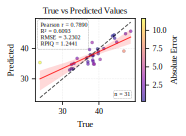

所有模型及预处理对比训练完成！


In [5]:
# 遍历所有 Label 文件
i = 0
for filename in os.listdir(labels_file):
    if filename.endswith(('.csv',)):
        label_path = os.path.join(labels_file, filename)
        label_name = os.path.splitext(filename)[0]

        # 读取并分割数据 (只需做一次)
        try:
            # 1. 加载、对齐数据，并划分数据集
            train_set, val_set, test_set = datalodaer.fused_data_split(spectra_path, image_features_path, label_path)
            # 每个set包含(X_spec, X_image, y, idx)
            # 2. 内部循环：遍历预处理方法
            for prep_name, prep_obj in preprocess_methods.items():
                i += 1
                print(f"NO.{i} [正在训练: {label_name} | 预处理: {prep_name}]========================")

                # =========================================
                # A. 数据融合处理 (关键步骤)
                # =========================================
                # 1. 光谱部分: 应用特定的预处理 (fit on train, transform all)
                spec_train_trans = prep_obj.fit_transform(train_set[0])
                spec_val_trans = prep_obj.transform(val_set[0])
                spec_test_trans = prep_obj.transform(test_set[0])

                # 2. 图像特征部分: 标准化 (XGB内无StandardScaler)
                scaler = StandardScaler()
                image_train_trans = scaler.fit_transform(train_set[1])
                image_val_trans = scaler.transform(val_set[1])
                image_test_trans = scaler.transform(test_set[1])

                # 3. 特征级融合 (Concatenation)
                X_train_fused = np.hstack([spec_train_trans, image_train_trans])
                X_val_fused = np.hstack([spec_val_trans, image_val_trans])
                X_test_fused = np.hstack([spec_test_trans, image_test_trans])

                # 4. 构建数据元组
                fused_train_set = (X_train_fused, train_set[2])
                fused_val_set = (X_val_fused, val_set[2])
                fused_test_set = (X_test_fused, test_set[2])

                # =========================================
                # B. 模型 2: XGBoost 回归
                # =========================================
                # 1. 构造路径名，包含预处理信息
                model_name = series_path
                notes = f"XGBoost + 透射光谱&Lab + {prep_name} 预处理"
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                figure_name = f"Fig_{series_path}-({label_name}; {prep_name})_{timestamp}"

                # 2. 使用 Optuna 寻找最优超参数 (使用处理后的数据)
                best_model, evaluation = model_trainer.tune_xgb_optuna(fused_train_set, fused_val_set)

                # 3. 预测 (使用处理后的数据)
                y_train_pred = best_model.predict(X_train_fused)
                y_val_pred = best_model.predict(X_val_fused)
                y_test_pred = best_model.predict(X_test_fused)

                # 4. 保存预测结果到csv文件
                results_df = pd.DataFrame({
                    'index': test_set[3],
                    'true_value': test_set[2],
                    'predicted_value': y_test_pred
                })
                results_df['label_name'] = label_name
                results_df['model_name'] = notes
                results_df['prediction_time'] = timestamp
                saver.save_prediction(results_df)

                # 6. 评估
                train_r, train_rmse, train_r2, train_rpiq, train_mae = utils.evaluate_model(train_set[2], y_train_pred)
                val_r, val_rmse, val_r2, val_rpiq, val_mae = utils.evaluate_model(val_set[2], y_val_pred)
                test_r, test_rmse, test_r2, test_rpiq, test_mae = utils.evaluate_model(test_set[2], y_test_pred)

                # 7. 创建当前实验的数据字典
                metrics_data = {
                    'Timestamp': [timestamp, timestamp, timestamp],
                    'Experiment': [label_name, label_name, label_name],
                    'Model': [model_name, model_name, model_name],
                    'Dataset': ['Training', 'Validation', 'Test'],
                    'Pearson_r': [train_r, val_r, test_r],
                    'RMSE': [train_rmse, val_rmse, test_rmse],
                    'R2': [train_r2, val_r2, test_r2],
                    'RPIQ': [train_rpiq, val_rpiq, test_rpiq],
                    'MAE': [train_mae, val_mae, test_mae],
                    'Notes': [notes, notes, notes]
                }
                # 8. 记录实验结果
                logger.log_metrics(metrics_data, model_name, label_name, parameters=evaluation)  # 记录日志
                ploter.correlation_scatter(6.5, 5, test_set[2], y_test_pred, figure_name)

        except Exception as e:
            print(f"执行失败: {filename} - 错误: {str(e)}")

print("所有模型及预处理对比训练完成！")